In [20]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from tqdm import tqdm
import pandas as pd
import sys
from typing import List
import numpy as np
import joblib
from pprint import pprint
import imodelsx.util
# import sasc.viz
import pickle as pkl
import json
from copy import deepcopy
from numpy.linalg import norm
import os
import pandas as pd
import neuro.sasc.modules.fmri_module
import imodelsx.util
from functools import partial
import numpy as np
from neuro.config import REGION_IDXS_DIR
import dvu
dvu.set_style()
subject = 'S03'
# subject = 'S02'

rois_dict = joblib.load(join(REGION_IDXS_DIR, f'rois_{subject}.jbl'))
if subject == 'S03':
    rois_dict['OPA'] = rois_dict['TOS']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# out_dir = 'repr_steering/greedy'
out_dir = f'repr_steering/{subject}/sampling_p=0.9_t=0.8'
rois = os.listdir(out_dir)
roi = 'RSC'
roi_dir = os.path.join(out_dir, roi)

In [ ]:
rois

In [ ]:
dfs = []
for seed_dir in os.listdir(out_dir):
    for roi_dir in os.listdir(os.path.join(out_dir, seed_dir)):
        full_dir = os.path.join(out_dir, seed_dir, roi_dir)
        fnames = os.listdir(full_dir)
        
# fnames = os.listdir(roi_dir)
# fnames = sorted(fnames, key=lambda x: int(x.split('_')[-1].split('.')[0]))

        # read the string in each file
        generations = []
        for fname in fnames:
            with open(os.path.join(full_dir, fname), 'r') as f:
                generations.append(f.read())
        # remove the longest common prefix from all generations
        longest_prefix = os.path.commonprefix(generations)
        generations = [gen[len(longest_prefix):] for gen in generations]
        # remove quote at the start
        generations = [gen[1:] if gen.startswith('"') else gen for gen in generations]

        df = pd.DataFrame({'generation': generations})
        df['fname'] = fnames
        df['ngrams_lists'] = df['generation'].apply(partial(imodelsx.util.generate_ngrams_list, ngrams=10, pad_starting_ngrams=False))
        df['seed'] = seed_dir
        df['roi'] = roi_dir
        dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

In [ ]:
# display with no truncation
with pd.option_context('display.max_colwidth', None):
    display(df)

### Evaluate driving

In [ ]:
mod = neuro.sasc.modules.fmri_module.fMRIModule(
    subject=f"UT{subject}",
    # checkpoint="facebook/opt-30b",
    checkpoint="huggyllama/llama-30b",
    init_model=True,
    restrict_weights=False,
)

In [ ]:
driving_vals = []
for i in tqdm(range(len(df))):
    ngrams_list = df['ngrams_lists'].iloc[i]
    if len(ngrams_list) == 0:
        driving_vals.append(np.array([np.nan]))
        continue
    voxel_preds = mod(ngrams_list, return_all=True)
    vals_par = voxel_preds[:, np.array(rois_dict[df['roi'].iloc[i]])].mean(axis=1)
    driving_vals.append(vals_par)
df['driving_vals'] = driving_vals
joblib.dump(df, f'repr_steering/{subject}/sampling_p=0.9_t=0.8/roi_driving_vals.jbl')

In [ ]:
df = joblib.load(f'repr_steering/{subject}/sampling_p=0.9_t=0.8/roi_driving_vals.jbl')

**compute probability of each generation under llama**

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_name = "meta-llama/Meta-Llama-3-70B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.bfloat16,
).eval()

In [ ]:
# evaluate the probability of a generation
log_likelihoods = []
perplexities = []
for i in tqdm(range(len(df))):
    generation = df['generation'].iloc[i]
    inputs = tokenizer(generation, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        log_likelihood = -outputs.loss.item() * inputs["input_ids"].size(1)
        perplexity = torch.exp(outputs.loss).item()
    print(f'Log likelihood: {log_likelihood}, Perplexity: {perplexity}')
    log_likelihoods.append(log_likelihood)
    perplexities.append(perplexity)
df['log_likelihood'] = log_likelihoods
df['perplexity'] = perplexities
joblib.dump(df, f'repr_steering/{subject}/sampling_p=0.9_t=0.8/roi_driving_vals_log_likelihoods.jbl')

In [21]:
df = joblib.load(f'repr_steering/{subject}/sampling_p=0.9_t=0.8/roi_driving_vals_log_likelihoods.jbl')
df['driving_val_mean'] = df['driving_vals'].apply(lambda x: np.nanmean(x))
df['reg_val'] = df['fname'].apply(lambda x: float(x.split('_')[-1].split('.')[0]))

/tmp/ipykernel_4112800/3155494519.py:2: RuntimeWarning: Mean of empty slice
  df['driving_val_mean'] = df['driving_vals'].apply(lambda x: np.nanmean(x))


<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'


/tmp/ipykernel_4112800/131975350.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Steering parameter $\lambda$')


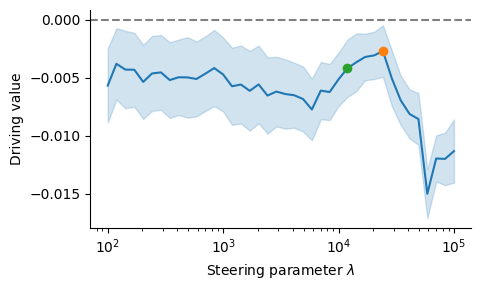

In [22]:
plt.figure(figsize=(5,3))
plt.axhline(0, color='gray', linestyle='--')
ax = sns.lineplot(data=df, x='reg_val', y='driving_val_mean', errorbar='se')

# get x-value of maximum on curve from sns lineplot
line = ax.lines[-1]           # seaborn draws one Line2D
xdata = line.get_xdata()
ydata = line.get_ydata()

idx = np.array(ydata).argmax()
peak_x = xdata[idx]
peak_y = ydata[idx]
plt.plot(peak_x, peak_y, 'o')  # plot the peak point in red

idx_ = idx - 4
plt.plot(xdata[idx_], ydata[idx_], 'o')  # plot the point 3 before peak in green

# sns.lineplot(data=df[df.roi == 'RSC'], x='reg_val', y='driving_val_mean', errorbar='se')
plt.xscale('log')
plt.ylabel('Driving value')
plt.xlabel('Steering parameter $\lambda$')
plt.tight_layout()
plt.savefig(f'repr_steering/{subject}_driving_vs_regval.pdf')

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4112800/344687368.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Steering parameter $\lambda$')


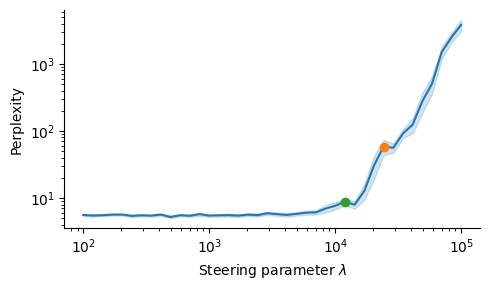

In [23]:
plt.figure(figsize=(5,3))
plt.axhline(0, color='gray', linestyle='--')
ax = sns.lineplot(data=df, x='reg_val', y='perplexity', errorbar='se')

# get x-value of maximum on curve from sns lineplot
line = ax.lines[-1]           # seaborn draws one Line2D
xdata = line.get_xdata()
ydata = line.get_ydata()

# idx = np.array(ydata).argmax()
peak_x = xdata[idx]
peak_y = ydata[idx]
plt.plot(peak_x, peak_y, 'o')  # plot the peak point in red

plt.plot(xdata[idx_], ydata[idx_], 'o')  # plot the point 3 before peak in green


# sns.lineplot(data=df[df.roi == 'RSC'], x='reg_val', y='driving_val_mean', errorbar='se')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Perplexity')
plt.xlabel('Steering parameter $\lambda$')
plt.tight_layout()
plt.savefig(f'repr_steering/{subject}_perplexity_vs_regval.pdf')

In [24]:
print('orange', xdata[idx], 'green', xdata[idx_])

orange 24244.0 green 11937.0
